In [1]:
# ==========================================
# Lesson 19 - Decision Trees
# ==========================================

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split

ee.Initialize(project="oc-flux")

Map = geemap.Map()

# Study Area (Yamuna River)
point = ee.Geometry.Point([77.2090, 28.6139])

collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(point)
    .filterDate("2023-01-01", "2023-12-31")
)

image = collection.median()

Map.centerObject(point, 10)

Map

Map(center=[28.613900000000005, 77.209], controls=(WidgetControl(options=['position', 'transparent_bg'], posit…

In [ ]:
Python Example

In [5]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Feature (Red Band)
X = np.array([
    [0.10],
    [0.15],
    [0.20],
    [0.25],
    [0.30]
])

# Target (POC)
y = np.array([
    2,
    3,
    5,
    7,
    9
])

model = DecisionTreeRegressor(random_state=42)

model.fit(X, y)

prediction = model.predict([[0.12]])

print("Predicted POC =", prediction)

Predicted POC = [2.]


In [ ]:
Visualizing a Decision Tree

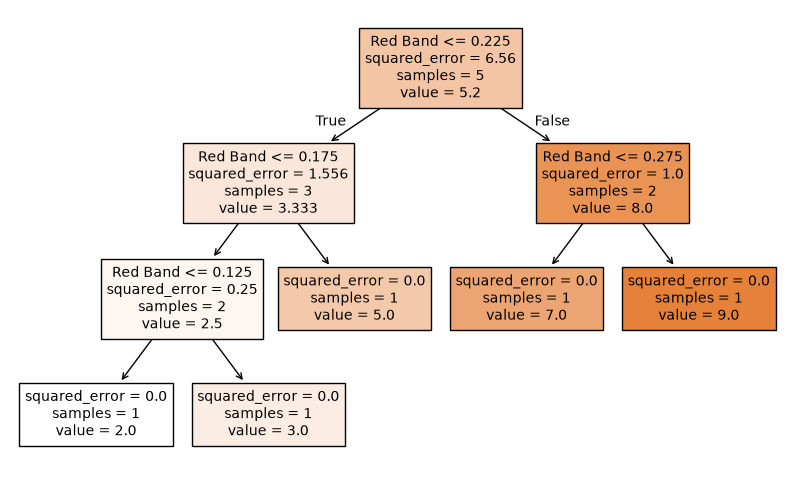

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plot_tree(
    model,
    filled=True,
    feature_names=["Red Band"]
)

plt.show()

In [ ]:
You will see:

Root node
Branches
Leaf nodes

This helps you understand how the model is making predictions.

In [ ]:
Controlling Tree Size

We can prevent overly complex trees.

Example:

In [4]:
model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)